## Imports

In [51]:
import warnings
warnings.filterwarnings('ignore', message='.*PyTorch API of nested tensors.*')
import math, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR   # LR decay scheduler
from torch.amp import autocast, GradScaler           # Mixed precision (AMP)
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.transforms import functional as VF
from collections import defaultdict, Counter
from typing import List, Tuple
import re, os
from torch.optim.swa_utils import AveragedModel       # EMA of model weights
from torch.utils.tensorboard import SummaryWriter      # TensorBoard logging


## Hyperparameters

In [52]:
# ── Core dimensions ──────────────────────────────────────────────────────────
EMBD_DIM    = 256        # Embedding dimension for both encoders
ATTEN_HEADS = 4          # Attention heads in transformer
# UPGRADED: increased from 3→6 layers for richer language representations
NUM_TX_LAYERS = 6        # Deeper text transformer (was 3)
DROPOUT     = 0.1        # Dropout for regularisation

# ── Training settings ─────────────────────────────────────────────────────────
batch_size  = 256        # Large batch = more negatives for contrastive learning
epochs      = 50
LR          = 3e-4       # AdamW learning rate
# ADDED: gradient accumulation simulates batch_size*GRAD_ACCUM_STEPS
# This means effective batch = 256*2 = 512 without extra VRAM
GRAD_ACCUM_STEPS = 2     # Accumulate gradients over N steps before optimizer.step()

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## Data Ingestion

In [53]:
def read_flickr30k_pairs(images_dir: str, token_file: str) -> List[Tuple[str, str]]:
    """Parses Flickr30k token file → list of (image_path, caption) pairs."""
    # Pre-cache image filenames for O(1) lookup (avoids repeated disk I/O)
    available_images = set(os.listdir(images_dir))
    pairs = []
    with open(token_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            left, caption = line.split("\t", 1)
            img_name = left.split("#")[0]
            if img_name in available_images:
                img_path = os.path.abspath(os.path.join(images_dir, img_name))
                pairs.append((img_path, caption))
    return pairs

flickr_images_dir = r"/home/zahid/Desktop/NanoVLM/data/flickr30k-images"
flickr_token_file = r"/home/zahid/Desktop/NanoVLM/data/flickr30k/results_20130124.token"


## Tokenizer (Simple Word-Level)

In [54]:
class SimpleTokenizer:
    def __init__(self, min_freq=2, max_vocab_size=10000):
        self.min_freq = min_freq
        self.max_vocab_size = max_vocab_size
        self.pad_token, self.unk_token = "<pad>", "<unk>"
        self.bos_token, self.eos_token = "<bos>", "<eos>"
        self.specials = [self.pad_token, self.unk_token, self.bos_token, self.eos_token]
        self.stoi = {tok: i for i, tok in enumerate(self.specials)}
        self.itos = list(self.specials)

    def _tokenize(self, text: str):
        return re.findall(r"\w+|[^\w\s]", text.lower())

    @property
    def pad_id(self): return self.stoi[self.pad_token]
    @property
    def unk_id(self): return self.stoi[self.unk_token]
    @property
    def bos_id(self): return self.stoi[self.bos_token]
    @property
    def eos_id(self): return self.stoi[self.eos_token]

    def build_vocab(self, texts: List[str]):
        counter = Counter()
        for t in texts:
            counter.update(self._tokenize(t))
        max_new = self.max_vocab_size - len(self.specials)
        sorted_tokens = sorted(
            [(tok, freq) for tok, freq in counter.items() if freq >= self.min_freq],
            key=lambda x: (-x[1], x[0])
        )[:max_new]
        for tok, _ in sorted_tokens:
            if tok not in self.stoi:
                self.stoi[tok] = len(self.itos)
                self.itos.append(tok)

    def encode(self, text: str, max_len=64):
        tokens = self._tokenize(text)
        ids = [self.bos_id] + [self.stoi.get(t, self.unk_id) for t in tokens] + [self.eos_id]
        return torch.tensor(ids[:max_len], dtype=torch.long)

    def decode(self, ids: torch.Tensor):
        if ids.ndim > 1:
            return [self.decode(seq) for seq in ids]
        tokens = [self.itos[i] for i in ids.tolist()
                  if i not in [self.pad_id, self.bos_id, self.eos_id]]
        return " ".join(tokens)


## Image Processing & Dataset

In [55]:
class ResizeLongestSide:
    """Resize so the longest side = max_side (downscale only)."""
    def __init__(self, max_side=224):
        self.max_side = max_side

    def __call__(self, img: Image.Image):
        w, h = img.size
        scale = self.max_side / max(w, h)
        if scale < 1.0:
            nw, nh = int(round(w * scale)), int(round(h * scale))
            img = VF.resize(img, (nh, nw), interpolation=transforms.InterpolationMode.BICUBIC)
        return img


class PairedImageTextDataset(torch.utils.data.Dataset):
    def __init__(self, pairs, tokenizer, img_transform=None, max_text_len=64):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.img_transform = img_transform
        self.max_text_len = max_text_len

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, text = self.pairs[idx]
        img = Image.open(img_path).convert("RGB")
        if self.img_transform:
            img = self.img_transform(img)
        toks = self.tokenizer.encode(text, max_len=self.max_text_len)
        return img, toks, text


def vlm_collate_fn(batch, pad_token_id=0):
    """Pads images and token sequences to the same size within a batch."""
    imgs, toks, texts = zip(*batch)

    # Pad images to the same H×W
    max_h = max(x.shape[1] for x in imgs)
    max_w = max(x.shape[2] for x in imgs)
    padded_imgs = []
    for x in imgs:
        pad = (0, max_w - x.shape[2], 0, max_h - x.shape[1])
        padded_imgs.append(F.pad(x, pad, value=0.0))
    batch_imgs = torch.stack(padded_imgs)

    # Pad token sequences and build attention mask
    max_l = max(t.shape[0] for t in toks)
    batch_toks = torch.full((len(toks), max_l), pad_token_id, dtype=torch.long)
    batch_mask = torch.zeros((len(toks), max_l), dtype=torch.bool)
    for i, t in enumerate(toks):
        batch_toks[i, :t.shape[0]] = t
        batch_mask[i, :t.shape[0]] = True

    return batch_imgs, batch_toks, batch_mask, list(texts)


## Build Dataset & DataLoaders

In [56]:
flickr_pairs = read_flickr30k_pairs(flickr_images_dir, flickr_token_file)
print(f"Total Flickr30k pairs: {len(flickr_pairs)}")

# ── FIX: Image-level split ────────────────────────────────────────────────────
img_to_captions = defaultdict(list)
for img_path, caption in flickr_pairs:
    img_to_captions[img_path].append(caption)

all_imgs = list(img_to_captions.keys())
random.seed(42)
random.shuffle(all_imgs)

split_idx  = int(0.9 * len(all_imgs))
train_imgs = set(all_imgs[:split_idx])
val_imgs   = set(all_imgs[split_idx:])

train_pairs = [(p, c) for p, c in flickr_pairs if p in train_imgs]
val_pairs   = [(p, c) for p, c in flickr_pairs if p in val_imgs]
print(f"Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}")

# Build vocabulary from TRAINING captions only (never look at val)
all_texts = [c for _, c in train_pairs]
tokenizer = SimpleTokenizer(min_freq=2, max_vocab_size=10000)
tokenizer.build_vocab(all_texts)
print(f"Vocab size: {len(tokenizer.itos)}")

# ── FIX NEW: Separate train/val transforms ────────────────────────────────────
# CLIP is trained on 224×224. Training uses heavy augmentation to prevent the
# image encoder memorising specific pixel patterns (key anti-overfitting trick).
# Validation uses a clean, deterministic pipeline so metrics are comparable.
_NORM_MEAN = [0.48145466, 0.4578275,  0.40821073]   # CLIP ImageNet stats
_NORM_STD  = [0.26862954, 0.26130258, 0.27577711]

img_tf_train = transforms.Compose([
    ResizeLongestSide(max_side=256),          # slightly larger before cropping
    transforms.RandomResizedCrop(224,         # FIX NEW: random crop — key augment
                                 scale=(0.65, 1.0),
                                 interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),   # FIX NEW: left-right flip
    transforms.ColorJitter(                   # FIX NEW: colour jitter
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),        # FIX NEW: occasional greyscale
    transforms.ToTensor(),
    transforms.Normalize(mean=_NORM_MEAN, std=_NORM_STD),
])

img_tf_val = transforms.Compose([
    ResizeLongestSide(max_side=224),           # deterministic resize
    transforms.CenterCrop(224),                # FIX NEW: fixed centre crop
    transforms.ToTensor(),
    transforms.Normalize(mean=_NORM_MEAN, std=_NORM_STD),
])

train_dataset = PairedImageTextDataset(train_pairs, tokenizer, img_transform=img_tf_train, max_text_len=64)
val_dataset   = PairedImageTextDataset(val_pairs,   tokenizer, img_transform=img_tf_val,   max_text_len=64)

collate = lambda b: vlm_collate_fn(b, pad_token_id=tokenizer.pad_id)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, collate_fn=collate)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True, collate_fn=collate)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Total Flickr30k pairs: 158915
Train pairs: 143020 | Val pairs: 15895
Vocab size: 10000
Train batches: 559 | Val batches: 63


## Image Encoder (CNN + Projection)

In [57]:
# UPGRADED: replaced the small scratch-built CNN with MobileNetV2 pretrained on ImageNet.
# MobileNetV2 already 'knows' visual concepts (dogs, cars, trees) before training starts,
# giving the model a huge head-start vs. learning from random weights.
# Strategy: freeze the first 14 feature blocks (low-level features),
#           fine-tune only the last 4 blocks + projection (high-level semantics).
# ADDED: a single MultiheadAttention block after the projection so the encoder
#        can model global context (not possible with pure conv layers).
from torchvision import models as tv_models

class ImageEncoder(nn.Module):
    """
    MobileNetV2 backbone (pretrained on ImageNet) → AdaptiveAvgPool → Dropout
    → Linear projection → Self-attention → LayerNorm → L2-normalised embedding.

    Improvements vs. original scratch CNN:
      • Pre-trained visual features  → much richer spatial representations
      • Frozen early layers           → avoids over-writing low-level edge detectors
      • Self-attention block          → global context modelling
      • MLP head after attention      → extra non-linear projection capacity
    """
    def __init__(self, embd_dim=EMBD_DIM, dropout=DROPOUT):
        super().__init__()

        # ── Backbone: MobileNetV2 features (output channels = 1280) ──────────────
        backbone = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.DEFAULT).features

        # Freeze the first 14 blocks (low-level texture/edge detectors).
        # Only fine-tune the last 4 blocks which contain high-level semantics.
        freeze_up_to = 14
        for i, child in enumerate(backbone.children()):
            if i < freeze_up_to:
                for p in child.parameters():
                    p.requires_grad = False

        self.backbone   = backbone
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))   # → [B, 1280, 1, 1]
        self.dropout    = nn.Dropout(p=dropout)

        # Project from MobileNetV2 output dim (1280) → EMBD_DIM
        self.projection = nn.Linear(1280, embd_dim)
        self.layernorm  = nn.LayerNorm(embd_dim)

        # ADDED: single self-attention block for global context
        self.attn = nn.MultiheadAttention(
            embed_dim=embd_dim, num_heads=ATTEN_HEADS, batch_first=True, dropout=dropout
        )

        # ADDED: small MLP head after attention (like real CLIP's projection head)
        self.mlp_head = nn.Sequential(
            nn.Linear(embd_dim, embd_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embd_dim * 2, embd_dim),
        )

    def forward(self, x):
        # Backbone feature extraction
        x = self.backbone(x)                          # [B, 1280, H', W']
        x = self.pool(x).flatten(1)                  # [B, 1280]
        x = self.dropout(self.projection(x))         # [B, embd_dim]

        # Self-attention: treat single vector as a sequence of length 1
        x = x.unsqueeze(1)                           # [B, 1, embd_dim]
        attn_out, _ = self.attn(x, x, x)
        x = (x + attn_out).squeeze(1)               # residual + squeeze → [B, embd_dim]

        # MLP head with residual
        x = x + self.mlp_head(x)                    # residual connection

        return F.normalize(self.layernorm(x), dim=-1)  # unit-norm embedding


## Text Encoder (Transformer)

In [58]:
# UPGRADED: TextEncoder now has:
#   • 6 transformer layers (was 3) — richer language representations
#   • MLP head after pooling — extra non-linear projection capacity (like real CLIP)
#   • Residual connection on MLP head — stabilises training

class TextEncoder(nn.Module):
    """
    Embedding → N-layer Transformer → mean pool → MLP head → L2-normalised embedding.

    Improvements vs. original:
      • num_layers=6  → deeper language model (was 3)
      • MLP projection head with GELU → richer embedding space
      • Residual on MLP head          → stable gradient flow
    """
    def __init__(self, embd_dim=EMBD_DIM, num_heads=ATTEN_HEADS,
                 vocab_size=10000, context_window=64,
                 num_layers=NUM_TX_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, embd_dim)
        self.position_embedding = nn.Embedding(context_window, embd_dim)

        # 6-layer transformer encoder (was 3)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embd_dim, nhead=num_heads,
            dim_feedforward=embd_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embd_dim)

        # ADDED: MLP projection head (mirrors real CLIP's text projection)
        # This gives the model extra capacity to map language representations
        # into the shared image-text embedding space.
        self.mlp_head = nn.Sequential(
            nn.Linear(embd_dim, embd_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embd_dim * 2, embd_dim),
        )

    def forward(self, toks, attention_mask=None):
        N, L = toks.shape
        pos = torch.arange(L, device=toks.device).unsqueeze(0)
        x   = self.token_embedding(toks) + self.position_embedding(pos)

        pad_mask = (attention_mask == 0) if attention_mask is not None else None
        x = self.transformer(x, src_key_padding_mask=pad_mask)   # [B, L, embd_dim]

        # Mean-pool over valid (non-padding) tokens
        x = x.mean(dim=1)                                         # [B, embd_dim]

        # MLP head with residual connection
        x = x + self.mlp_head(x)

        return F.normalize(self.norm(x), dim=-1)                  # unit-norm embedding


## CLIP Contrastive Loss

In [59]:
# UPGRADED: added label_smoothing=0.1 to both cross-entropy terms.
# Label smoothing prevents the model from being over-confident on easy pairs
# and forces it to learn from harder, more ambiguous pairs — improves generalisation.

class CLIPLoss(nn.Module):
    """
    Symmetric cross-entropy over the image-text similarity matrix.

    Improvements vs. original:
      • label_smoothing=0.1 → reduces over-confidence, better generalisation
      • Learnable logit_scale (temperature) unchanged — already a good design
    """
    def __init__(self, label_smoothing=0.1):
        super().__init__()
        # Learnable log-scale temperature (real CLIP initialisation)
        self.logit_scale    = nn.Parameter(torch.ones([]) * (1 / 0.07))
        # ADDED: store label smoothing factor
        self.label_smoothing = label_smoothing

    def forward(self, image_emb, txt_emb):
        scale   = self.logit_scale.exp().clamp(max=100)
        logits  = image_emb @ txt_emb.T * scale      # [B, B] similarity matrix
        targets = torch.arange(image_emb.size(0), device=image_emb.device)

        # UPGRADED: label_smoothing=0.1 on both directions
        loss_i = F.cross_entropy(logits,   targets, label_smoothing=self.label_smoothing)
        loss_t = F.cross_entropy(logits.T, targets, label_smoothing=self.label_smoothing)
        return (loss_i + loss_t) / 2.0


## Model, Optimizer & Scheduler

In [60]:
img_enc   = ImageEncoder().to(device)
txt_enc   = TextEncoder(vocab_size=len(tokenizer.itos)).to(device)
criterion = CLIPLoss().to(device)   # learnable temperature lives here

# All parameters: both encoders + the learnable temperature
params    = list(img_enc.parameters()) + list(txt_enc.parameters()) + list(criterion.parameters())

# FIX ↑: AdamW with stronger weight_decay (5e-3 vs old 1e-4)
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)

# FIX NEW: Linear warmup + cosine decay (standard for CLIP).
# Warmup gradually ramps LR from ~0 → LR over WARMUP_EPOCHS, then cosine-decays.
# This prevents large noisy updates from destabilising the model at the start.
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(WARMUP_EPOCHS)   # linear ramp
    # cosine decay from LR → ~0 over remaining epochs
    progress = (epoch - WARMUP_EPOCHS) / max(1, epochs - WARMUP_EPOCHS)
    return max(1e-6 / LR, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# FIX: Mixed-precision scaler — trains in float16 for speed + lower VRAM
scaler = GradScaler('cuda')

# ── Resume from checkpoint if one exists ────────────────────────────────────
import os
start_epoch   = 0
best_val_loss_init = float('inf')

CKPT_FILES = {
    'img_enc'  : 'best_img_enc.pth',
    'txt_enc'  : 'best_txt_enc.pth',
    'criterion': 'best_criterion.pth',
    'optimizer': 'best_optimizer.pth',
    'scheduler': 'best_scheduler.pth',
    'meta'     : 'best_meta.pth',
}

if all(os.path.exists(v) for v in list(CKPT_FILES.values())[:3]):   # weights must exist
    print("\n✓ Checkpoint found — resuming training...")
    img_enc.load_state_dict(torch.load(CKPT_FILES['img_enc'],   map_location=device))
    txt_enc.load_state_dict(torch.load(CKPT_FILES['txt_enc'],   map_location=device))
    criterion.load_state_dict(torch.load(CKPT_FILES['criterion'], map_location=device))
    if os.path.exists(CKPT_FILES['optimizer']):
        optimizer.load_state_dict(torch.load(CKPT_FILES['optimizer'], map_location=device))
    if os.path.exists(CKPT_FILES['scheduler']):
        scheduler.load_state_dict(torch.load(CKPT_FILES['scheduler'], map_location=device))
    if os.path.exists(CKPT_FILES['meta']):
        meta = torch.load(CKPT_FILES['meta'], map_location='cpu')
        start_epoch        = meta.get('epoch', 0) + 1
        best_val_loss_init = meta.get('best_val_loss', float('inf'))
    print(f"  Resuming from epoch {start_epoch + 1}/{epochs}  |  best val loss so far: {best_val_loss_init:.4f}")
else:
    print("No checkpoint found — starting from epoch 1.")

print(f"ImageEncoder params : {sum(p.numel() for p in img_enc.parameters()):,}")
print(f"TextEncoder params  : {sum(p.numel() for p in txt_enc.parameters()):,}")
print(f"Temperature (init)  : {criterion.logit_scale.item():.4f}")

# ── EMA (Exponential Moving Average) ──────────────────────────────────────────
# EMA keeps a shadow copy of the model weights that is updated as:
#     ema_weight = decay * ema_weight + (1 - decay) * current_weight
# This produces smoother, more stable embeddings for evaluation.
# A decay of 0.999 means the EMA updates slowly — it averages over ~1000 steps.
# We use EMA copies only for EVALUATION; training still uses the live models.
EMA_DECAY = 0.999

# avg_fn: called as avg_fn(ema_param, model_param, num_averaged)
# It blends the current EMA weight with the new model weight.
ema_img = AveragedModel(
    img_enc,
    avg_fn=lambda ema, new, n: EMA_DECAY * ema + (1 - EMA_DECAY) * new
)
ema_txt = AveragedModel(
    txt_enc,
    avg_fn=lambda ema, new, n: EMA_DECAY * ema + (1 - EMA_DECAY) * new
)
print(f"EMA decay           : {EMA_DECAY}")

# ── TensorBoard Writer ────────────────────────────────────────────────────────
# TensorBoard logs scalars (loss, LR, temperature) to a directory.
# View them by running:  tensorboard --logdir=runs/nanoVLM
# Then open http://localhost:6006 in your browser.
tb_writer = SummaryWriter(log_dir="runs/nanoVLM")
print(f"TensorBoard logs    : runs/nanoVLM")


No checkpoint found — starting from epoch 1.
ImageEncoder params : 3,078,400
TextEncoder params  : 7,578,368
Temperature (init)  : 14.2857
EMA decay           : 0.999
TensorBoard logs    : runs/nanoVLM


## Pre-Training Embedding Snapshot

In [61]:
# Record embeddings BEFORE training to compare with post-training
img_enc.eval(); txt_enc.eval()
with torch.no_grad():
    sample_idx = random.randrange(len(val_dataset))
    sample_img, sample_toks, sample_caption = val_dataset[sample_idx]
    s_img  = sample_img.unsqueeze(0).to(device)
    s_toks = sample_toks.unsqueeze(0).to(device)
    s_mask = (s_toks != tokenizer.pad_id).to(device)

    pre_img_emb = img_enc(s_img).squeeze(0).cpu().numpy()
    pre_txt_emb = txt_enc(s_toks, attention_mask=s_mask).squeeze(0).cpu().numpy()

cos_sim_pre = float(
    np.dot(pre_img_emb, pre_txt_emb) /
    (np.linalg.norm(pre_img_emb) * np.linalg.norm(pre_txt_emb) + 1e-12)
)
print(f"Pre-training cosine similarity: {cos_sim_pre:.4f}")
print(f"Img emb shape: {pre_img_emb.shape} | Txt emb shape: {pre_txt_emb.shape}")


Pre-training cosine similarity: 0.0709
Img emb shape: (256,) | Txt emb shape: (256,)


## Training Loop

In [62]:
# Safety fallback — in case checkpoint cell was skipped
if 'start_epoch' not in dir():
    start_epoch = 0
if 'best_val_loss_init' not in dir():
    best_val_loss_init = float('inf')
if 'CKPT_FILES' not in dir():
    CKPT_FILES = {
        'img_enc'  : 'best_img_enc.pth',
        'txt_enc'  : 'best_txt_enc.pth',
        'criterion': 'best_criterion.pth',
        'optimizer': 'best_optimizer.pth',
        'scheduler': 'best_scheduler.pth',
        'meta'     : 'best_meta.pth',
    }

print(f"Starting training on {device} for {epochs} epochs...", flush=True)
print(f"Epochs to run: {start_epoch + 1} → {epochs}", flush=True)
print(f"Hyperparams: dropout={DROPOUT} | weight_decay={WEIGHT_DECAY} | "
      f"label_smooth={LABEL_SMOOTH} | warmup={WARMUP_EPOCHS}ep | patience={EARLY_STOP_PATIENCE}ep", flush=True)

best_val_loss    = best_val_loss_init
train_losses, val_losses = [], []   # track for plotting
no_improve_count = 0                # FIX NEW: early-stopping counter

for epoch in range(start_epoch, epochs):
    # ── Training ─────────────────────────────────────────────────────────────
    img_enc.train(); txt_enc.train(); criterion.train()
    total_loss = 0.0

    for batch_idx, (batch_imgs, batch_toks, batch_mask, _) in enumerate(train_loader):
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        batch_toks = batch_toks.to(device, non_blocking=True)
        batch_mask = batch_mask.to(device, non_blocking=True)

        # ADDED: gradient accumulation — zero_grad only at start of each accumulation window.
        # Effective batch size = batch_size × GRAD_ACCUM_STEPS (more negatives, stronger signal).
        if batch_idx % GRAD_ACCUM_STEPS == 0:
            optimizer.zero_grad()

        with autocast('cuda'):
            img_emb = img_enc(batch_imgs)
            txt_emb = txt_enc(batch_toks, attention_mask=batch_mask)
            # Divide loss by GRAD_ACCUM_STEPS so accumulated gradients are correctly scaled.
            loss    = criterion(img_emb, txt_emb) / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        # ADDED: only step optimizer after accumulating GRAD_ACCUM_STEPS gradients
        # (or at the very last batch of the epoch).
        is_last_batch = (batch_idx + 1) == len(train_loader)
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or is_last_batch:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

        # Clamp logit_scale in log-space after each optimiser step (OpenAI practice)
        with torch.no_grad():
            criterion.logit_scale.clamp_(max=np.log(100))

        # ── EMA update ───────────────────────────────────────────────────────
        # After each optimizer step, update the shadow EMA copies.
        # These copies are used ONLY for evaluation — they produce smoother
        # embeddings because they average over many training steps.
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or is_last_batch:
            ema_img.update_parameters(img_enc)
            ema_txt.update_parameters(txt_enc)

        # Multiply back by GRAD_ACCUM_STEPS to log the true unscaled loss value.
        total_loss += loss.item() * GRAD_ACCUM_STEPS

        if batch_idx % 20 == 0:
            true_loss = loss.item() * GRAD_ACCUM_STEPS
            print(f"  Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} "
                  f"| Loss: {true_loss:.4f} | Temp: {criterion.logit_scale.exp().item():.2f}",
                  flush=True)

        # ── TensorBoard: log every batch ─────────────────────────────────────
        # global_step gives TensorBoard a unique x-axis value across all epochs.
        global_step = epoch * len(train_loader) + batch_idx
        tb_writer.add_scalar("batch/train_loss", loss.item() * GRAD_ACCUM_STEPS, global_step)
        tb_writer.add_scalar("batch/temperature", criterion.logit_scale.exp().item(), global_step)

    avg_train_loss = total_loss / len(train_loader)

    # FIX: step the LR scheduler once per epoch (warmup + cosine)
    scheduler.step()

    # ── Validation ───────────────────────────────────────────────────────────
    img_enc.eval(); txt_enc.eval(); criterion.eval()
    val_loss = 0.0
    with torch.no_grad():
        for b_imgs, b_toks, b_mask, _ in val_loader:
            b_imgs = b_imgs.to(device, non_blocking=True)
            b_toks = b_toks.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)
            with autocast('cuda'):
                val_loss += criterion(img_enc(b_imgs), txt_enc(b_toks, attention_mask=b_mask)).item()

    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    current_lr = scheduler.get_last_lr()[0]
    print(f"\n--- Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.4f} "
          f"| Val: {avg_val_loss:.4f} | LR: {current_lr:.2e} | Temp: {criterion.logit_scale.exp().item():.2f}", flush=True)

    # ── TensorBoard: log epoch-level metrics ─────────────────────────────────
    # These appear as smooth epoch-level curves in TensorBoard.
    tb_writer.add_scalar("epoch/train_loss", avg_train_loss, epoch + 1)
    tb_writer.add_scalar("epoch/val_loss",   avg_val_loss,   epoch + 1)
    tb_writer.add_scalar("epoch/learning_rate", current_lr,  epoch + 1)
    tb_writer.add_scalar("epoch/temperature", criterion.logit_scale.exp().item(), epoch + 1)

    # ── Checkpoint (best val loss) ────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        no_improve_count = 0
        torch.save(img_enc.state_dict(),   CKPT_FILES['img_enc'])
        torch.save(txt_enc.state_dict(),   CKPT_FILES['txt_enc'])
        torch.save(criterion.state_dict(), CKPT_FILES['criterion'])
        torch.save(optimizer.state_dict(), CKPT_FILES['optimizer'])
        torch.save(scheduler.state_dict(), CKPT_FILES['scheduler'])
        torch.save({'epoch': epoch, 'best_val_loss': best_val_loss}, CKPT_FILES['meta'])
        print(f"  ✓ Checkpoint saved (epoch {epoch+1}, val_loss={best_val_loss:.4f}).", flush=True)
    else:
        no_improve_count += 1
        print(f"  ✗ No improvement ({no_improve_count}/{EARLY_STOP_PATIENCE})", flush=True)

    # FIX NEW: early stopping
    if no_improve_count >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1} — no val improvement for {EARLY_STOP_PATIENCE} epochs.", flush=True)
        break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

# ── Close TensorBoard writer ─────────────────────────────────────────────────
# Flush any buffered data and release the log file handle.
tb_writer.close()
print("TensorBoard logs saved to runs/nanoVLM")


Starting training on cuda for 50 epochs...
Epochs to run: 1 → 50
Hyperparams: dropout=0.1 | weight_decay=0.005 | label_smooth=0.1 | warmup=3ep | patience=5ep
  Epoch 1/50 | Batch 0/559 | Loss: 12.4975 | Temp: 100.00
  Epoch 1/50 | Batch 20/559 | Loss: 9.3435 | Temp: 99.93
  Epoch 1/50 | Batch 40/559 | Loss: 6.6241 | Temp: 99.83
  Epoch 1/50 | Batch 60/559 | Loss: 5.9251 | Temp: 99.73
  Epoch 1/50 | Batch 80/559 | Loss: 5.6452 | Temp: 99.62
  Epoch 1/50 | Batch 100/559 | Loss: 5.5493 | Temp: 99.51
  Epoch 1/50 | Batch 120/559 | Loss: 5.4446 | Temp: 99.42
  Epoch 1/50 | Batch 140/559 | Loss: 5.3916 | Temp: 99.35
  Epoch 1/50 | Batch 160/559 | Loss: 5.3343 | Temp: 99.30
  Epoch 1/50 | Batch 180/559 | Loss: 5.2058 | Temp: 99.27
  Epoch 1/50 | Batch 200/559 | Loss: 5.1022 | Temp: 99.24
  Epoch 1/50 | Batch 220/559 | Loss: 4.9975 | Temp: 99.20
  Epoch 1/50 | Batch 240/559 | Loss: 4.9864 | Temp: 99.17
  Epoch 1/50 | Batch 260/559 | Loss: 4.9604 | Temp: 99.14
  Epoch 1/50 | Batch 280/559 | Los

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>Exception ignored in:   File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__

<function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>Traceback (most recent call last):

      File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()Traceback (most recent call last):
    
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      File "/

  Epoch 5/50 | Batch 460/559 | Loss: 2.5718 | Temp: 88.07
  Epoch 5/50 | Batch 480/559 | Loss: 2.6203 | Temp: 87.98
  Epoch 5/50 | Batch 500/559 | Loss: 2.5053 | Temp: 87.88


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>
Traceback (most recent call last):
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


  Epoch 5/50 | Batch 520/559 | Loss: 2.6496 | Temp: 87.79
  Epoch 5/50 | Batch 540/559 | Loss: 2.6570 | Temp: 87.69

--- Epoch 5/50 | Train: 2.6139 | Val: 3.7544 | LR: 2.99e-04 | Temp: 87.60
  ✓ Checkpoint saved (epoch 5, val_loss=3.7544).
  Epoch 6/50 | Batch 0/559 | Loss: 2.3140 | Temp: 87.60
  Epoch 6/50 | Batch 20/559 | Loss: 2.3863 | Temp: 87.51
  Epoch 6/50 | Batch 40/559 | Loss: 2.3398 | Temp: 87.41
  Epoch 6/50 | Batch 60/559 | Loss: 2.4849 | Temp: 87.30
  Epoch 6/50 | Batch 80/559 | Loss: 2.2357 | Temp: 87.20
  Epoch 6/50 | Batch 100/559 | Loss: 2.3111 | Temp: 87.12
  Epoch 6/50 | Batch 120/559 | Loss: 2.3610 | Temp: 87.03
  Epoch 6/50 | Batch 140/559 | Loss: 2.4685 | Temp: 86.93
  Epoch 6/50 | Batch 160/559 | Loss: 2.4805 | Temp: 86.83
  Epoch 6/50 | Batch 180/559 | Loss: 2.4707 | Temp: 86.73
  Epoch 6/50 | Batch 200/559 | Loss: 2.4190 | Temp: 86.66
  Epoch 6/50 | Batch 220/559 | Loss: 2.5805 | Temp: 86.54
  Epoch 6/50 | Batch 240/559 | Loss: 2.4088 | Temp: 86.44
  Epoch 6/50

...

  Epoch 10/50 | Batch 80/559 | Loss: 1.7986 | Temp: 77.04
  Epoch 10/50 | Batch 100/559 | Loss: 1.8152 | Temp: 76.97
  Epoch 10/50 | Batch 120/559 | Loss: 1.8396 | Temp: 76.89
  Epoch 10/50 | Batch 140/559 | Loss: 1.8450 | Temp: 76.79
  Epoch 10/50 | Batch 160/559 | Loss: 1.8202 | Temp: 76.70
  Epoch 10/50 | Batch 180/559 | Loss: 1.7729 | Temp: 76.62
  Epoch 10/50 | Batch 200/559 | Loss: 1.8702 | Temp: 76.53
  Epoch 10/50 | Batch 220/559 | Loss: 1.9119 | Temp: 76.46
  Epoch 10/50 | Batch 240/559 | Loss: 1.8566 | Temp: 76.37
  Epoch 10/50 | Batch 260/559 | Loss: 1.7705 | Temp: 76.28
  Epoch 10/50 | Batch 280/559 | Loss: 1.8028 | Temp: 76.19
  Epoch 10/50 | Batch 300/559 | Loss: 1.8735 | Temp: 76.10
  Epoch 10/50 | Batch 320/559 | Loss: 1.9099 | Temp: 76.01
  Epoch 10/50 | Batch 340/559 | Loss: 1.7711 | Temp: 75.93
  Epoch 10/50 | Batch 360/559 | Loss: 1.9401 | Temp: 75.84
  Epoch 10/50 | Batch 380/559 | Loss: 1.7762 | Temp: 75.76
  Epoch 10/50 | Batch 400/559 | Loss: 1.9221 | Temp: 75.6

Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920><function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920><function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>
Exception ignored in: 

Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__

  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils


--- Epoch 10/50 | Train: 1.8483 | Val: 3.7826 | LR: 2.84e-04 | Temp: 74.99
  ✗ No improvement (1/5)
  Epoch 11/50 | Batch 0/559 | Loss: 1.7772 | Temp: 74.99


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>
Traceback (most recent call last):
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x734e47b17920>
Traceback (most recent call last):
  File "/home/zahid/miniconda3/envs/new-agentic-rag/lib/python3.11/site-packages/torch/utils/data/dataloader.py", l

  Epoch 11/50 | Batch 20/559 | Loss: 1.7326 | Temp: 74.92
  Epoch 11/50 | Batch 40/559 | Loss: 1.7363 | Temp: 74.82
  Epoch 11/50 | Batch 60/559 | Loss: 1.7290 | Temp: 74.74
  Epoch 11/50 | Batch 80/559 | Loss: 1.8008 | Temp: 74.65
  Epoch 11/50 | Batch 100/559 | Loss: 1.6967 | Temp: 74.56
  Epoch 11/50 | Batch 120/559 | Loss: 1.7872 | Temp: 74.47
  Epoch 11/50 | Batch 140/559 | Loss: 1.7730 | Temp: 74.38
  Epoch 11/50 | Batch 160/559 | Loss: 1.7308 | Temp: 74.32
  Epoch 11/50 | Batch 180/559 | Loss: 1.8148 | Temp: 74.23
  Epoch 11/50 | Batch 200/559 | Loss: 1.7012 | Temp: 74.17
  Epoch 11/50 | Batch 220/559 | Loss: 1.8794 | Temp: 74.08
  Epoch 11/50 | Batch 240/559 | Loss: 1.7151 | Temp: 74.00
  Epoch 11/50 | Batch 260/559 | Loss: 1.8205 | Temp: 73.91
  Epoch 11/50 | Batch 280/559 | Loss: 1.7617 | Temp: 73.82
  Epoch 11/50 | Batch 300/559 | Loss: 1.7423 | Temp: 73.75
  Epoch 11/50 | Batch 320/559 | Loss: 1.7919 | Temp: 73.67
  Epoch 11/50 | Batch 340/559 | Loss: 1.7787 | Temp: 73.58
 

## Training Curves

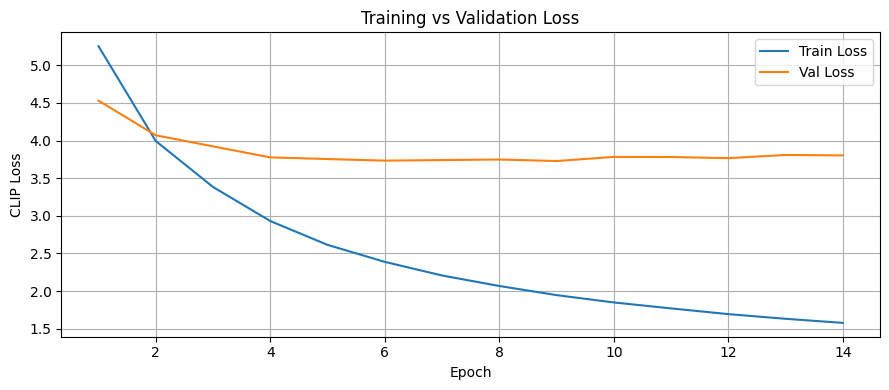

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses)+1),   val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("CLIP Loss")
plt.title("Training vs Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()


## Post-Training Evaluation

In [64]:
# Load best checkpoint
img_enc.load_state_dict(torch.load("best_img_enc.pth", map_location=device))
txt_enc.load_state_dict(torch.load("best_txt_enc.pth", map_location=device))
img_enc.eval(); txt_enc.eval()

# Compute cosine similarity on same sample as pre-training snapshot
with torch.no_grad():
    post_img_emb = img_enc(s_img).squeeze(0).cpu().numpy()
    post_txt_emb = txt_enc(s_toks, attention_mask=s_mask).squeeze(0).cpu().numpy()

cos_sim_post = float(
    np.dot(post_img_emb, post_txt_emb) /
    (np.linalg.norm(post_img_emb) * np.linalg.norm(post_txt_emb) + 1e-12)
)
print(f"Pre-training  cosine similarity : {cos_sim_pre:.4f}")
print(f"Post-training cosine similarity : {cos_sim_post:.4f}")
print(f"Improvement                     : {cos_sim_post - cos_sim_pre:+.4f}")


Pre-training  cosine similarity : 0.0709
Post-training cosine similarity : 0.3714
Improvement                     : +0.3005


## Top-K Retrieval Accuracy

In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# UPGRADED: Full-epoch batch-local average Recall using EMA models.
# ══════════════════════════════════════════════════════════════════════════════
#
# HOW THIS WORKS:
# ───────────────
# 1. We use the EMA (shadow) copies of the models, NOT the live training models.
#    EMA weights are smoother because they average over many training steps.
#
# 2. We iterate over EVERY batch in val_loader (not just one batch).
#    For each batch, we compute the B×B similarity matrix and check if
#    the correct match appears in the top-K predictions.
#
# 3. We average the per-batch Recall across all batches.
#    NOTE: This is "batch-local" Recall — each batch is a small retrieval pool.
#    True global Recall would require embedding the entire val set into one
#    giant matrix. Batch-local is a practical, fast approximation.
#
# 4. We also compute the overall validation loss with EMA models.

def evaluate_recall(img_encoder, txt_encoder, loss_fn, loader, ks=(1, 5, 10)):
    """
    Compute batch-local average Recall@K and average loss over an entire DataLoader.

    Args:
        img_encoder:  image encoder model (or EMA wrapper)
        txt_encoder:  text encoder model (or EMA wrapper)
        loss_fn:      CLIPLoss module
        loader:       DataLoader to evaluate on
        ks:           tuple of K values for Recall@K

    Returns:
        recalls:  dict {K: average_recall} e.g. {1: 0.12, 5: 0.42, 10: 0.58}
        avg_loss: average CLIP loss over all batches
    """
    img_encoder.eval()
    txt_encoder.eval()

    total_samples = 0       # total number of image-text pairs evaluated
    total_loss    = 0.0     # sum of batch losses
    # correct_at_k[k] = number of samples where the correct match was in top-K
    correct_at_k  = {k: 0 for k in ks}

    with torch.no_grad():
        for b_imgs, b_toks, b_mask, _ in loader:
            b_imgs = b_imgs.to(device, non_blocking=True)
            b_toks = b_toks.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            with autocast('cuda'):
                img_emb = img_encoder(b_imgs)                    # [B, embd_dim]
                txt_emb = txt_encoder(b_toks, attention_mask=b_mask)  # [B, embd_dim]
                batch_loss = loss_fn(img_emb, txt_emb)

            total_loss += batch_loss.item()
            B = img_emb.size(0)
            total_samples += B

            # Image→Text similarity matrix [B, B]
            # Because embeddings are L2-normalised, dot product = cosine similarity.
            scores = img_emb @ txt_emb.T

            # For each image i, the correct text is at index i (diagonal).
            # Check if i appears in the top-K columns for row i.
            for k in ks:
                if k > B:
                    # If batch is smaller than K, skip (can't have top-K with fewer items)
                    correct_at_k[k] += B  # trivially all correct
                    continue
                top_k_indices = torch.topk(scores, k=k, dim=1).indices  # [B, k]
                # targets[i] = i (the correct match is always on the diagonal)
                targets = torch.arange(B, device=scores.device).unsqueeze(1)  # [B, 1]
                # Check: does the target index appear anywhere in this row's top-K?
                hits = (top_k_indices == targets).any(dim=1)  # [B] boolean
                correct_at_k[k] += hits.sum().item()

    # Average over all samples
    recalls  = {k: correct_at_k[k] / total_samples for k in ks}
    avg_loss = total_loss / len(loader)
    return recalls, avg_loss


# ── Run evaluation with EMA models ───────────────────────────────────────────
# Load best checkpoint into the live models first
img_enc.load_state_dict(torch.load("best_img_enc.pth", map_location=device))
txt_enc.load_state_dict(torch.load("best_txt_enc.pth", map_location=device))

# Update EMA copies to match the best checkpoint
# (EMA tracks the live model, so after loading best weights, sync EMA)
ema_img.update_parameters(img_enc)
ema_txt.update_parameters(txt_enc)

print("Evaluating with EMA models on full validation set...\n")

# Evaluate using EMA shadow models (smoother embeddings)
# ema_img.module and ema_txt.module are the actual nn.Module with averaged weights.
recalls, ema_val_loss = evaluate_recall(
    ema_img.module, ema_txt.module, criterion, val_loader, ks=(1, 5, 10)
)

print(f"EMA Val Loss: {ema_val_loss:.4f}")
print(f"──────────────────────────────")
for k, r in recalls.items():
    print(f"  Image→Text Recall@{k:>2d}: {r:.1%}")

# Also evaluate with the live (non-EMA) models for comparison
print(f"\n--- Comparison: Live model (no EMA) ---")
recalls_live, live_val_loss = evaluate_recall(
    img_enc, txt_enc, criterion, val_loader, ks=(1, 5, 10)
)
print(f"Live Val Loss: {live_val_loss:.4f}")
for k, r in recalls_live.items():
    ema_r = recalls[k]
    diff  = ema_r - r
    print(f"  Image→Text Recall@{k:>2d}: {r:.1%}  (EMA {'+' if diff >= 0 else ''}{diff:.1%})")


Evaluating with EMA models on full validation set...

EMA Val Loss: 3.6801
──────────────────────────────
  Image→Text Recall@ 1: 13.6%
  Image→Text Recall@ 5: 55.0%
  Image→Text Recall@10: 71.6%

--- Comparison: Live model (no EMA) ---
Live Val Loss: 3.6239
  Image→Text Recall@ 1: 13.9%  (EMA -0.3%)
  Image→Text Recall@ 5: 56.6%  (EMA -1.5%)
  Image→Text Recall@10: 73.0%  (EMA -1.4%)
